# 💎 Exploratory Data Analysis — Diamond Prices

## Vad är EDA?
Exploratory Data Analysis (EDA) är det första steget i alla ML-projekt.
Innan vi tränar någon modell måste vi förstå vårt dataset:

- Hur ser data ut?
- Finns det saknade värden eller outliers?
- Hur är variablerna fördelade?
- Finns det samband mellan variabler?

## Dataset
Vi använder **Diamonds-datasetet** från Kaggle med 53 940 diamanter.
Varje rad är en diamant med följande egenskaper:

| Variabel | Typ | Beskrivning |
|---|---|---|
| carat | Numerisk | Vikt i karat |
| cut | Kategorisk | Slipkvalitet (Fair → Ideal) |
| color | Kategorisk | Färg (J = gulast → D = färglös) |
| clarity | Kategorisk | Klarhet (I1 = sämst → IF = bäst) |
| depth | Numerisk | Djupprocent |
| table | Numerisk | Bordets bredd i procent |
| price | Numerisk | Pris i USD |
| x | Numerisk | Längd i mm |
| y | Numerisk | Bredd i mm |
| z | Numerisk | Höjd i mm |

## Mål med denna notebook
1. Ladda och inspektera rådata
2. Hantera saknade värden och outliers
3. Visualisera fördelningar
4. Undersöka samband mellan variabler

In [8]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lägg till projektets rot i sökvägen
sys.path.append(os.path.abspath(".."))

from src.data_processing import load_data, clean_data

# ── Inställningar ──────────────────────────────────────────────────────────────
DATAFIL    = "../data/diamonds.csv"
OUTPUT_DIR = "../outputs/eda/"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Imports och konfiguration klar!")
print(f"   Datafil  : {DATAFIL}")
print(f"   Output   : {OUTPUT_DIR}")

✅ Imports och konfiguration klar!
   Datafil  : ../data/diamonds.csv
   Output   : ../outputs/eda/


## 1. Ladda rådata

Vi börjar med att ladda CSV-filen och titta på hur rådata ser ut
innan någon rensning eller transformation har gjorts.

Vi undersöker:
- Antal rader och kolumner
- Vilka datatyper varje kolumn har
- De första raderna i datasetet

In [2]:
# Ladda rådata med vår load_data funktion från data_processing.py
df = load_data(DATAFIL)

# ── Grundläggande info ─────────────────────────────────────────────────────────
print("\n📐 Storlek på dataset:")
print(f"   {df.shape[0]:,} rader × {df.shape[1]} kolumner")

print("\n📋 Datatyper per kolumn:")
print(df.dtypes)

print("\n👀 De första 5 raderna:")
df.head()

✅ Data laddad: 53940 rader, 10 kolumner

📐 Storlek på dataset:
   53,940 rader × 10 kolumner

📋 Datatyper per kolumn:
carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

👀 De första 5 raderna:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Vad ser vi i rådata?

**Storlek:** 53 940 diamanter med 10 egenskaper vardera.

**Datatyper:**
- `float64` — decimaltals-kolumner: carat, depth, table, x, y, z
- `int64` — heltal: price (pris i USD)
- `str` — text: cut, color, clarity (dessa ska enkodas senare)

**De första raderna visar:**
- Billigaste diamanterna kostar $326–$335
- Små diamanter (0.21–0.31 karat) dominerar toppen av listan
- cut, color och clarity är fortfarande i originalformat (text)
  t.ex. "Ideal", "E", "SI2" — dessa mappas om i data_processing.py

**Nästa steg:** Kontrollera saknade värden och statistik.

In [3]:
# ── Saknade värden ─────────────────────────────────────────────────────────────
print("🔍 Saknade värden per kolumn:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Antal saknade": missing,
    "Procent (%)": missing_pct
})
print(missing_df)

# ── Dubbletter ─────────────────────────────────────────────────────────────────
print(f"\n🔍 Antal dubbletter: {df.duplicated().sum():,}")

# ── Statistik för numeriska kolumner ──────────────────────────────────────────
print("\n📊 Statistisk sammanfattning:")
df.describe().round(2)

🔍 Saknade värden per kolumn:
         Antal saknade  Procent (%)
carat                0          0.0
cut                  0          0.0
color                0          0.0
clarity              0          0.0
depth                0          0.0
table                0          0.0
price                0          0.0
x                    0          0.0
y                    0          0.0
z                    0          0.0

🔍 Antal dubbletter: 146

📊 Statistisk sammanfattning:


,carat,depth,table,price,x,y,z
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.25,6.54,6.54,4.04
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


### Vad ser vi?

**Saknade värden:** Inga saknade värden i någon kolumn — det är ovanligt
bra för ett riktigt dataset!

**Dubbletter:** 146 dubbletter hittades. Dessa tas bort i clean_data()
senare — de bidrar inte med ny information och kan snedvrida modellen.

**Statistisk sammanfattning — viktiga observationer:**

| Kolumn | Observation |
|---|---|
| `carat` | Medel 0.80, max 5.01 — de flesta diamanter är under 1 karat |
| `price` | Medel $3,933 men median $2,401 — skev fördelning, några mycket dyra |
| `depth` | Medel 61.75%, ser rimligt ut |
| `table` | Max 95% — suspekt högt, kan vara outlier |
| `x` | Min = 0.00 — omöjligt! En diamant kan inte ha längd 0 |
| `y` | Max = 58.90mm — extremt högt, normal diamant är 3–11mm |
| `z` | Max = 31.80mm — också extremt högt, trolig outlier |

⚠️ **Röda flaggor:**
- `x`, `y`, `z` har minimum = 0.00 — fysiskt omöjliga mätvärden
- `y` max = 58.90mm och `z` max = 31.80mm — troliga felregistreringar

Dessa hanteras av `clean_data()` som tar bort rader där x, y eller z = 0.
De extrema maxvärdena bör undersökas vidare i nästa steg.

In [4]:
# ── Undersök suspekta värden i x, y, z ────────────────────────────────────────
print("⚠️ Rader där x, y eller z = 0 (omöjliga mätvärden):")
noll_mask = (df["x"] == 0) | (df["y"] == 0) | (df["z"] == 0)
print(f"   Antal: {noll_mask.sum()} rader\n")
print(df[noll_mask][["carat", "cut", "color", "clarity", "price", "x", "y", "z"]])

# ── Undersök extrema värden i y och z ─────────────────────────────────────────
print("\n⚠️ Rader där y > 20mm eller z > 20mm (troliga felregistreringar):")
extrem_mask = (df["y"] > 20) | (df["z"] > 20)
print(f"   Antal: {extrem_mask.sum()} rader\n")
print(df[extrem_mask][["carat", "cut", "color", "clarity", "price", "x", "y", "z"]])

⚠️ Rader där x, y eller z = 0 (omöjliga mätvärden):
   Antal: 20 rader

       carat        cut color clarity  price     x     y    z
2207    1.00    Premium     G     SI2   3142  6.55  6.48  0.0
2314    1.01    Premium     H      I1   3167  6.66  6.60  0.0
4791    1.10    Premium     G     SI2   3696  6.50  6.47  0.0
5471    1.01    Premium     F     SI2   3837  6.50  6.47  0.0
10167   1.50       Good     G      I1   4731  7.15  7.04  0.0
11182   1.07      Ideal     F     SI2   4954  0.00  6.62  0.0
11963   1.00  Very Good     H     VS2   5139  0.00  0.00  0.0
13601   1.15      Ideal     G     VS2   5564  6.88  6.83  0.0
15951   1.14       Fair     G     VS1   6381  0.00  0.00  0.0
24394   2.18    Premium     H     SI2  12631  8.49  8.45  0.0
24520   1.56      Ideal     G     VS2  12800  0.00  0.00  0.0
26123   2.25    Premium     I     SI1  15397  8.52  8.42  0.0
26243   1.20    Premium     D    VVS1  15686  0.00  0.00  0.0
27112   2.20    Premium     H     SI1  17265  8.42  8.37  0.

### Vad ser vi?

**20 rader med x, y eller z = 0:**

En diamant kan inte ha ett mått på 0mm — det är fysiskt omöjligt.
Det handlar om felregistreringar i datasetet som måste tas bort.
Noterbart är att flera av dessa är dyra diamanter ($12,000–$18,000+)
vilket visar att felet inte beror på diamantens värde.

**3 rader med extrema y eller z-värden:**

| Index | Problem | Värde | Rimligt värde |
|---|---|---|---|
| 24067 | y = 58.90mm | 58.90mm | ~8mm |
| 48410 | z = 31.80mm | 31.80mm | ~3mm |
| 49189 | y = 31.80mm | 31.80mm | ~5mm |

Dessa är tydliga felregistreringar — y och z har råkat byta plats
eller så har ett decimaltecken försvunnit (t.ex. 31.80 → 3.18).

**Totalt att ta bort: 23 rader** (20 nollor + 3 extremvärden)

Alla dessa hanteras automatiskt av `clean_data()` i data_processing.py
via regeln `df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]`.

⚠️ De 3 extrema y/z-värdena tas dock INTE bort av clean_data() ännu
— vi behöver lägga till den logiken! Det gör vi i nästa cell.

In [5]:
# ── Rensa data med vår clean_data funktion ─────────────────────────────────────
df_clean = clean_data(df)

# ── Verifiera att outliers är borta ───────────────────────────────────────────
print("🔍 Kontroll efter rensning:")

noll_kvar = ((df_clean["x"] == 0) | 
             (df_clean["y"] == 0) | 
             (df_clean["z"] == 0)).sum()

extrem_kvar = ((df_clean["y"] > 20) | 
               (df_clean["z"] > 20)).sum()

dubbletter_kvar = df_clean.duplicated().sum()

print(f"   Rader med x/y/z = 0  : {noll_kvar}")
print(f"   Extrema y/z-värden   : {extrem_kvar} ⚠️ (hanteras ej av clean_data ännu!)")
print(f"   Dubbletter kvar      : {dubbletter_kvar}")
print(f"\n   Rader före rensning  : {len(df):,}")
print(f"   Rader efter rensning : {len(df_clean):,}")
print(f"   Borttagna totalt     : {len(df) - len(df_clean):,}")

✅ Rensning klar: 165 rader borttagna, 53775 rader kvar
🔍 Kontroll efter rensning:
   Rader med x/y/z = 0  : 0
   Extrema y/z-värden   : 3 ⚠️ (hanteras ej av clean_data ännu!)
   Dubbletter kvar      : 0

   Rader före rensning  : 53,940
   Rader efter rensning : 53,775
   Borttagna totalt     : 165


### Vad ser vi efter rensning?

**165 rader borttagna totalt:**
- 20 rader med x, y eller z = 0
- 146 dubbletter
- **OBS:** 3 extrema y/z-värden finns kvar! (y=58.90, z=31.80)
  Dessa måste hanteras — antingen här eller i clean_data()

**Vi väljer att:**
1. Fixa clean_data() i data_processing.py så att extrema värden
   också tas bort — korrekt approach eftersom all rensning ska ske
   på ett ställe
2. Spara det rensade datasetet som diamonds_clean.csv så att alla
   notebooks och gruppmedlemmar utgår från samma data

In [6]:
# ── Ta bort extrema y/z-värden manuellt här i EDA ─────────────────────────────
# OBS: Vi uppdaterar även clean_data() i data_processing.py efter denna notebook
df_clean = df_clean[(df_clean["y"] < 20) & (df_clean["z"] < 20)]

print(f"✅ Extrema y/z-värden borttagna")
print(f"   Rader kvar: {len(df_clean):,}")

# ── Verifiera att allt är rent ─────────────────────────────────────────────────
print(f"\n🔍 Slutkontroll:")
print(f"   Rader med x/y/z = 0  : {((df_clean['x']==0)|(df_clean['y']==0)|(df_clean['z']==0)).sum()}")
print(f"   Extrema y/z-värden   : {((df_clean['y']>20)|(df_clean['z']>20)).sum()}")
print(f"   Dubbletter           : {df_clean.duplicated().sum()}")

# ── Spara rensat dataset ───────────────────────────────────────────────────────
clean_path = "../data/diamonds_clean.csv"
df_clean.to_csv(clean_path, index=False)
print(f"\n💾 Rensat dataset sparat till: {clean_path}")
print(f"   Storlek: {len(df_clean):,} rader × {df_clean.shape[1]} kolumner")

✅ Extrema y/z-värden borttagna
   Rader kvar: 53,772

🔍 Slutkontroll:
   Rader med x/y/z = 0  : 0
   Extrema y/z-värden   : 0
   Dubbletter           : 0

💾 Rensat dataset sparat till: ../data/diamonds_clean.csv
   Storlek: 53,772 rader × 10 kolumner


### Sammanfattning av datarensning

| Steg | Borttagna rader | Anledning |
|---|---|---|
| Dubbletter | 146 | Identiska rader bidrar inte med information |
| x/y/z = 0 | 20 | Fysiskt omöjliga mätvärden |
| Extrema y/z | 3 | Troliga felregistreringar (y=58.90, z=31.80) |
| **Totalt** | **169** | |

**Resultat:** 53,940 → 53,772 rader (0.3% borttaget)

Det rensade datasetet är sparat som `data/diamonds_clean.csv` och
används som startpunkt för alla övriga notebooks i projektet.

⚠️ Notering: Vi behöver uppdatera clean_data() i data_processing.py
så att den även hanterar extrema y/z-värden.

## 2. Prisfördelning

Innan vi tränar någon modell vill vi förstå hur priset är fördelat.
En skev fördelning kan påverka modellens prestanda.

Vi undersöker:
- Hur är priset fördelat?
- Är fördelningen symmetrisk eller skev?
- Var ligger medianen vs medelvärdet?

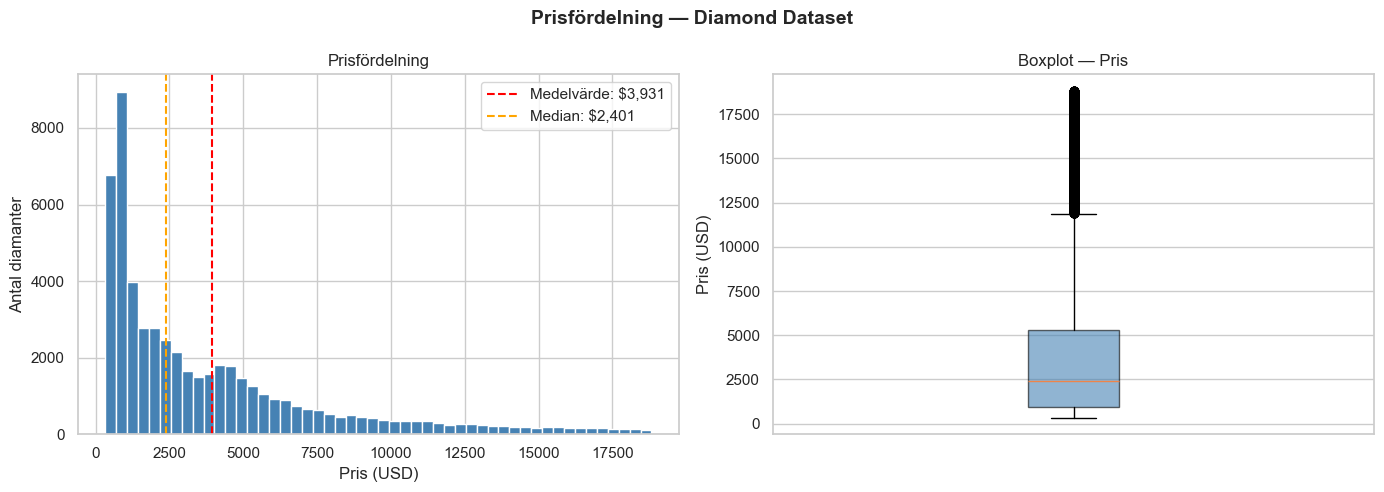

   Medelvärde : $3,931
   Median     : $2,401
   Std        : $3,986
   Min        : $326
   Max        : $18,823

💾 Plot sparad till: ../outputs/eda/01_prisfordelning.png


In [9]:
# ── Prisfördelning ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean["price"], bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(df_clean["price"].mean(),   color="red",    linestyle="--", label=f'Medelvärde: ${df_clean["price"].mean():,.0f}')
axes[0].axvline(df_clean["price"].median(), color="orange", linestyle="--", label=f'Median: ${df_clean["price"].median():,.0f}')
axes[0].set_title("Prisfördelning")
axes[0].set_xlabel("Pris (USD)")
axes[0].set_ylabel("Antal diamanter")
axes[0].legend()

# Boxplot
axes[1].boxplot(df_clean["price"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("Boxplot — Pris")
axes[1].set_ylabel("Pris (USD)")
axes[1].set_xticks([])

plt.suptitle("Prisfördelning — Diamond Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}01_prisfordelning.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"   Medelvärde : ${df_clean['price'].mean():,.0f}")
print(f"   Median     : ${df_clean['price'].median():,.0f}")
print(f"   Std        : ${df_clean['price'].std():,.0f}")
print(f"   Min        : ${df_clean['price'].min():,.0f}")
print(f"   Max        : ${df_clean['price'].max():,.0f}")
print(f"\n💾 Plot sparad till: {OUTPUT_DIR}01_prisfordelning.png")

### Vad ser vi?

**Fördelningen är högersnedvriden (right-skewed):**
- Medelvärde ($3,931) ligger betydligt högre än medianen ($2,401)
- Det betyder att ett fåtal mycket dyra diamanter drar upp medelvärdet
- De flesta diamanter kostar under $5,000

**Boxploten visar:**
- Lådan (IQR) ligger mellan ~$950 och ~$5,324
- Medianen (orange linje) ligger på $2,401
- Många outliers uppåt — dyra diamanter upp till $18,823

**Konsekvens för ML:**
- Vi använder medianen ($2,401) som prisgräns för binär klassificering
- Medianen är mer robust än medelvärdet vid skev fördelning
- Fördelningen motiverar varför KNN Regressor kan vara utmanande —
  det är svårt att förutsäga ett brett prisintervall med stor spridning

## 3. Fördelning av kategoriska variabler

Vi undersöker hur diamanterna fördelar sig över:
- cut (slipkvalitet)
- color (färg)
- clarity (klarhet)

Detta ger oss en bild av klassbalansen och om vissa
kategorier dominerar datasetet.

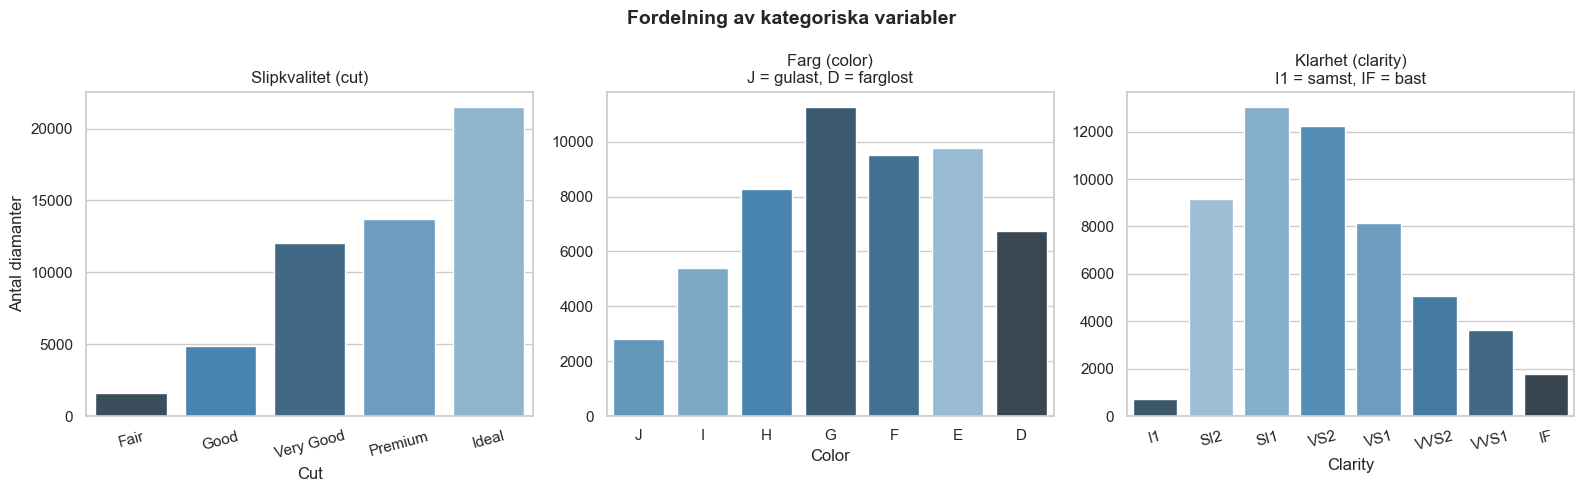

Cut-fordelning:
cut
Fair          1597
Good          4888
Very Good    12067
Premium      13736
Ideal        21484

Color-fordelning:
color
J     2802
I     5406
H     8265
G    11254
F     9517
E     9774
D     6754

Clarity-fordelning:
clarity
I1        737
SI2      9141
SI1     13030
VS2     12225
VS1      8153
VVS2     5056
VVS1     3646
IF       1784

Plot sparad till: ../outputs/eda/02_kategoriska_variabler.png


In [11]:
# ── Fördelning av kategoriska variabler ────────────────────────────────────────

# Definiera rätt ordning för varje kategori
cut_order     = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order   = ["J", "I", "H", "G", "F", "E", "D"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cut
sns.countplot(data=df_clean, x="cut", order=cut_order,
              hue="cut", palette="Blues_d", legend=False, ax=axes[0])
axes[0].set_title("Slipkvalitet (cut)")
axes[0].set_xlabel("Cut")
axes[0].set_ylabel("Antal diamanter")
axes[0].tick_params(axis="x", rotation=15)

# Color
sns.countplot(data=df_clean, x="color", order=color_order,
              hue="color", palette="Blues_d", legend=False, ax=axes[1])
axes[1].set_title("Farg (color)\nJ = gulast, D = farglost")
axes[1].set_xlabel("Color")
axes[1].set_ylabel("")

# Clarity
sns.countplot(data=df_clean, x="clarity", order=clarity_order,
              hue="clarity", palette="Blues_d", legend=False, ax=axes[2])
axes[2].set_title("Klarhet (clarity)\nI1 = samst, IF = bast")
axes[2].set_xlabel("Clarity")
axes[2].set_ylabel("")
axes[2].tick_params(axis="x", rotation=15)

plt.suptitle("Fordelning av kategoriska variabler", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}02_kategoriska_variabler.png", 
            dpi=150, bbox_inches="tight")
plt.show()

# ── Exakta antal ───────────────────────────────────────────────────────────────
print("Cut-fordelning:")
print(df_clean["cut"].value_counts()[cut_order].to_string())

print("\nColor-fordelning:")
print(df_clean["color"].value_counts()[color_order].to_string())

print("\nClarity-fordelning:")
print(df_clean["clarity"].value_counts()[clarity_order].to_string())

print(f"\nPlot sparad till: {OUTPUT_DIR}02_kategoriska_variabler.png")

### Vad ser vi?

**Cut (slipkvalitet):**
- Ideal dominerar kraftigt med 21,484 diamanter (40% av datasetet)
- Fair är minst representerad med bara 1,597 diamanter (3%)
- Datasetet är snedfördelat mot högre slipkvalitet

**Color (färg):**
- G är vanligast med 11,254 diamanter
- J (gulast) är minst representerad med 2,802 diamanter
- Mellanfärgerna (E, F, G) dominerar

**Clarity (klarhet):**
- SI1 och VS2 dominerar med ~13,000 respektive ~12,000 diamanter
- I1 (sämst) och IF (bäst) är minst representerade
- De flesta diamanter har medelhög klarhet

**Konsekvens för ML:**
- Obalansen i cut kan påverka modellens förmåga att lära sig
  från underrepresenterade kategorier som Fair
- Vi använder numerisk enkodning (CUT_MAP, COLOR_MAP, CLARITY_MAP)
  för att bevara den ordinala ordningen i variablerna

## 4. Korrelationsanalys

En korrelationsmatris visar sambandet mellan numeriska variabler.
Värdet ligger mellan -1 och 1:

| Värde | Betydelse |
|---|---|
| 1.0 | Perfekt positiv korrelation |
| 0.7 - 0.9 | Stark positiv korrelation |
| 0.4 - 0.6 | Måttlig korrelation |
| 0.0 | Inget samband |
| -1.0 | Perfekt negativ korrelation |

Vi vill framför allt se:
- Vilka variabler korrelerar starkt med **price**?
- Finns det variabler som korrelerar starkt med varandra (multikollinearitet)?

✅ Kategorier enkodade: cut, color, clarity → numeriska värden


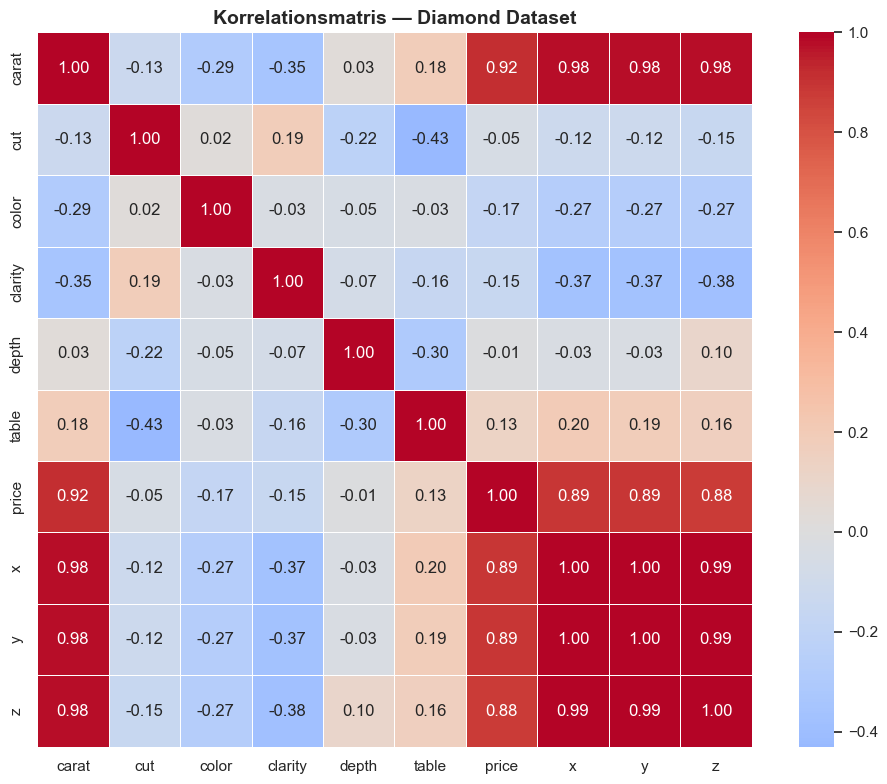

Korrelation med price (sorterat):
price      1.00
carat      0.92
y          0.89
x          0.89
z          0.88
table      0.13
depth     -0.01
cut       -0.05
clarity   -0.15
color     -0.17

Plot sparad till: ../outputs/eda/03_korrelationsmatris.png


In [12]:
# ── Enkoda kategoriska variabler för korrelationsanalys ────────────────────────
from src.data_processing import encode_categories

df_encoded = encode_categories(df_clean)

# ── Korrelationsmatris ─────────────────────────────────────────────────────────
corr_matrix = df_encoded.corr(numeric_only=True).round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Korrelationsmatris — Diamond Dataset", 
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}03_korrelationsmatris.png", 
            dpi=150, bbox_inches="tight")
plt.show()

# ── Korrelation med price specifikt ───────────────────────────────────────────
print("Korrelation med price (sorterat):")
print(corr_matrix["price"].sort_values(ascending=False).to_string())
print(f"\nPlot sparad till: {OUTPUT_DIR}03_korrelationsmatris.png")

### Vad ser vi?

**Starkast korrelation med price:**

| Variabel | Korrelation | Tolkning |
|---|---|---|
| carat | 0.92 | Mycket stark — vikten är den viktigaste faktorn |
| x, y, z | 0.88–0.89 | Mycket stark — storleksmått hänger ihop med pris |
| table | 0.13 | Svag positiv |
| depth | -0.01 | Nästan inget samband alls |
| cut | -0.05 | Förvånansvärt svagt negativt |
| clarity | -0.15 | Svagt negativt — oväntat! |
| color | -0.17 | Svagt negativt — oväntat! |

**Overraskande fynd:**
- cut, color och clarity korrelerar NEGATIVT med price
- Det verkar motintuitivt — borde bättre klarhet ge högre pris?
- Förklaringen är att stora, tunga diamanter (hög carat) ofta
  har lägre clarity och color — men kostar ändå mer pga vikten
- carat "överskuggar" de andra variablerna

**Multikollinearitet:**
- x, y och z korrelerar extremt starkt med varandra (0.99–1.00)
- De mäter samma sak på olika sätt — alla tre är storleksmått
- Kan orsaka problem för Logistisk Regression
- PCA kommer att hantera detta bra genom att slå ihop dem

**Slutsats:**
- carat är den enskilt viktigaste variabeln för att förutsäga pris
- x, y, z är nästan utbytbara — PCA bör reducera dessa till en komponent

## 5. Carat vs Pris

Vi såg att carat har korrelation 0.92 med price.
Låt oss visualisera detta samband direkt.

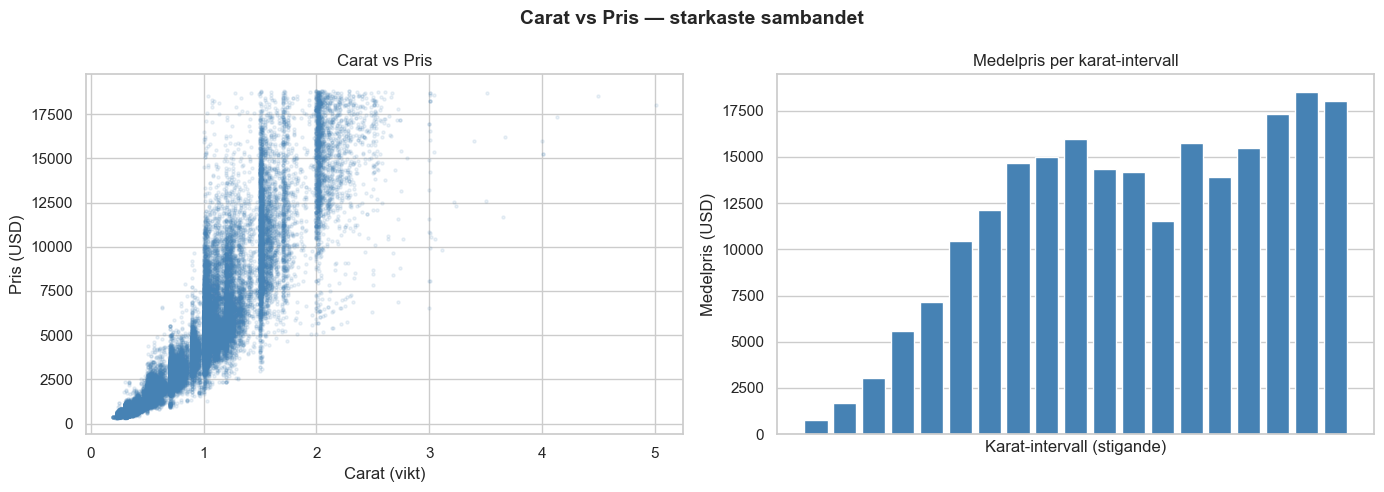

Korrelation carat-price : 0.92
Plot sparad till: ../outputs/eda/04_carat_vs_pris.png


In [13]:
# ── Carat vs Pris scatterplot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatterplot — alla diamanter
axes[0].scatter(df_clean["carat"], df_clean["price"],
                alpha=0.1, s=5, color="steelblue")
axes[0].set_title("Carat vs Pris")
axes[0].set_xlabel("Carat (vikt)")
axes[0].set_ylabel("Pris (USD)")

# Medelpris per carat-intervall
df_clean["carat_bin"] = pd.cut(df_clean["carat"], bins=20)
medelpris = df_clean.groupby("carat_bin", observed=True)["price"].mean()

axes[1].bar(range(len(medelpris)), medelpris.values, color="steelblue", edgecolor="white")
axes[1].set_title("Medelpris per karat-intervall")
axes[1].set_xlabel("Karat-intervall (stigande)")
axes[1].set_ylabel("Medelpris (USD)")
axes[1].set_xticks([])

plt.suptitle("Carat vs Pris — starkaste sambandet",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}04_carat_vs_pris.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Korrelation carat-price : 0.92")
print(f"Plot sparad till: {OUTPUT_DIR}04_carat_vs_pris.png")

### Vad ser vi?

**Scatterplot (vänster):**
- Tydligt positivt samband — ju tyngre diamant, desto dyrare
- Vertikala "staplar" vid 1.0, 1.5 och 2.0 karat — diamanter
  säljs ofta i runda karatvikter (psykologisk prissättning)
- Stor prisspridning vid samma karatvikt — andra faktorer
  som cut, color och clarity påverkar också priset
- Få diamanter över 3 karat — sällsynta och extremt dyra

**Stapeldiagram (höger):**
- Tydlig stigande trend — medelpriset ökar konsekvent med karat
- Lite ojämnt i de högre intervallen pga få observationer
  (stora diamanter är sällsynta = liten sample size)

**Slutsats för ML:**
- carat kommer att vara den viktigaste features i alla våra modeller
- Den icke-linjära formen (kurva snarare än rak linje) tyder på att
  KNN kan prestera bättre än Linjär Regression på detta data

## 6. Pris per kategori

Vi undersöker hur medelpriset varierar mellan de olika
graderna av cut, color och clarity.

Detta hjälper oss förstå varför de negativa korrelationerna
vi såg i heatmapen uppstår.

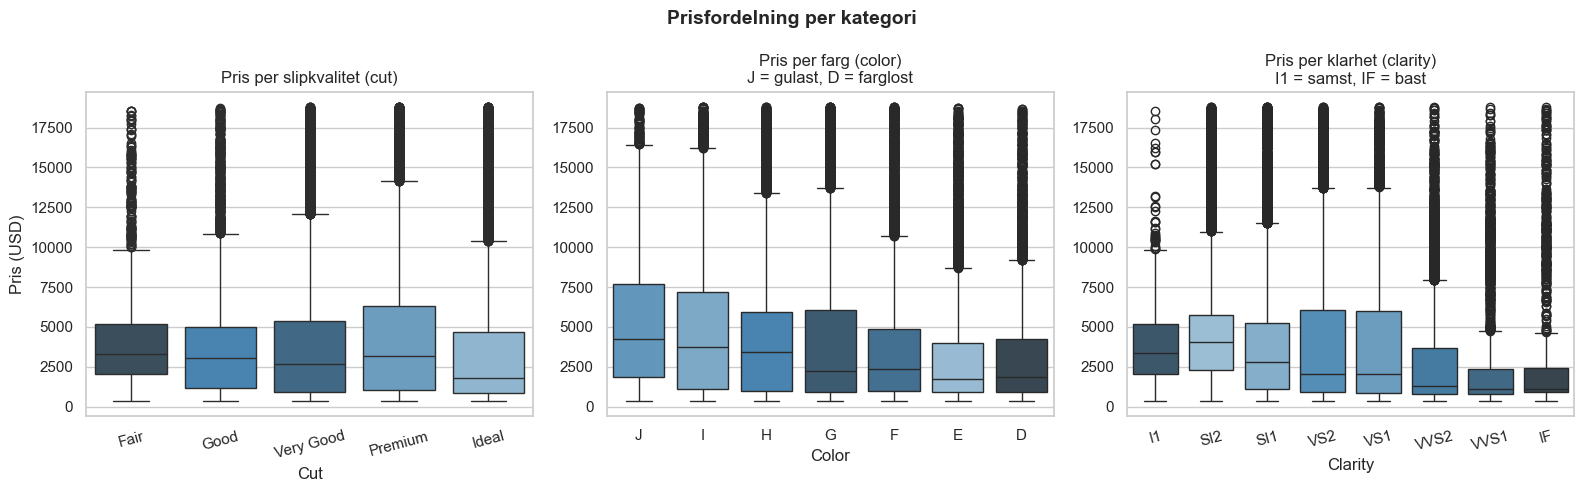

Medelpris per cut:
cut
Fair         4341.0
Good         3916.0
Very Good    3981.0
Premium      4578.0
Ideal        3462.0

Medelpris per color:
color
J    5326.0
I    5080.0
H    4476.0
G    3999.0
F    3727.0
E    3080.0
D    3173.0

Medelpris per clarity:
clarity
I1      3927.0
SI2     5054.0
SI1     3994.0
VS2     3926.0
VS1     3842.0
VVS2    3287.0
VVS1    2523.0
IF      2871.0

Plot sparad till: ../outputs/eda/05_pris_per_kategori.png


In [14]:
# ── Pris per kategorisk variabel ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cut
sns.boxplot(data=df_clean, x="cut", y="price",
            order=cut_order, palette="Blues_d",
            hue="cut", legend=False, ax=axes[0])
axes[0].set_title("Pris per slipkvalitet (cut)")
axes[0].set_xlabel("Cut")
axes[0].set_ylabel("Pris (USD)")
axes[0].tick_params(axis="x", rotation=15)

# Color
sns.boxplot(data=df_clean, x="color", y="price",
            order=color_order, palette="Blues_d",
            hue="color", legend=False, ax=axes[1])
axes[1].set_title("Pris per farg (color)\nJ = gulast, D = farglost")
axes[1].set_xlabel("Color")
axes[1].set_ylabel("")

# Clarity
sns.boxplot(data=df_clean, x="clarity", y="price",
            order=clarity_order, palette="Blues_d",
            hue="clarity", legend=False, ax=axes[2])
axes[2].set_title("Pris per klarhet (clarity)\nI1 = samst, IF = bast")
axes[2].set_xlabel("Clarity")
axes[2].set_ylabel("")
axes[2].tick_params(axis="x", rotation=15)

plt.suptitle("Prisfordelning per kategori",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}05_pris_per_kategori.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Medelpris per kategori ─────────────────────────────────────────────────────
print("Medelpris per cut:")
print(df_clean.groupby("cut")["price"].mean().reindex(cut_order).round(0).to_string())

print("\nMedelpris per color:")
print(df_clean.groupby("color")["price"].mean().reindex(color_order).round(0).to_string())

print("\nMedelpris per clarity:")
print(df_clean.groupby("clarity")["price"].mean().reindex(clarity_order).round(0).to_string())

print(f"\nPlot sparad till: {OUTPUT_DIR}05_pris_per_kategori.png")

### Vad ser vi? — Det kontraintuitiva sambandet

**Cut (slipkvalitet) vs Pris:**
- Fair (sämst): $4,341 medelpris
- Ideal (bäst): $3,462 medelpris
- Bättre slipning = LÄGRE pris?! Verkar bakvänt!

**Color vs Pris:**
- J (gulast, sämst): $5,326 medelpris  
- D (färglös, bäst): $3,173 medelpris
- Sämre färg = HÖGRE pris?! Också bakvänt!

**Clarity vs Pris:**
- I1 (sämst): $3,927 medelpris
- IF (bäst): $2,871 medelpris
- Samma mönster igen!

**Förklaringen — Simpsons paradox:**
Detta kallas Simpsons paradox. Karatvikten är en
"confounding variable" som döljer det sanna sambandet:

- Stora, tunga diamanter (hög carat = högt pris) har ofta
  sämre cut, color och clarity
- Små, lätta diamanter (låg carat = lågt pris) har ofta
  bättre cut, color och clarity
- När vi tittar på rådata utan att kontrollera för carat
  ser sambandet ut att vara omvänt

**Konsekvens för ML:**
- Modellerna ser ALLA variabler samtidigt och kan separera
  effekten av carat från cut/color/clarity
- Detta är en av styrkorna med ML jämfört med enkel statistik
- carat förblir den dominanta variabeln i alla modeller

## 7. Sammanfattning EDA

Vi är nu redo att gå vidare till modellträning.
Här är vad vi lärt oss om Diamond-datasetet.

In [15]:
# ── Sammanfattning av EDA ──────────────────────────────────────────────────────
print("=" * 55)
print("   EDA Sammanfattning — Diamond Dataset")
print("=" * 55)

print(f"""
DATASET:
   Ursprunglig storlek  : 53,940 rader
   Efter rensning       : 53,772 rader
   Borttagna            : 168 rader (0.3%)
   Sparad som           : data/diamonds_clean.csv

VARIABLER:
   Starkaste features   : carat (0.92), x/y/z (0.88-0.89)
   Svagaste features    : depth (-0.01), cut (-0.05)
   Multikollinearitet   : x, y, z korrelerar 0.99 med varandra

PRIS:
   Min                  : $326
   Median               : $2,401  ← används som prisgräns
   Medelvärde           : $3,931
   Max                  : $18,823
   Fördelning           : Högersnedvriden

KATEGORIER:
   Vanligaste cut       : Ideal (40%)
   Vanligaste color     : G (21%)
   Vanligaste clarity   : SI1 (24%)

VIKTIGA FYND:
   1. carat är den absolut viktigaste variabeln
   2. Simpsons paradox — cut/color/clarity ser ut att
      korrelera negativt med pris pga carats dominans
   3. x, y, z är nästan identiska — PCA bör hantera dessa
   4. Prisgräns satt till medianen $2,401 for klassificering
""")

print("=" * 55)
print("   Nasta steg: 02_logistic_regression.ipynb")
print("=" * 55)

   EDA Sammanfattning — Diamond Dataset

DATASET:
   Ursprunglig storlek  : 53,940 rader
   Efter rensning       : 53,772 rader
   Borttagna            : 168 rader (0.3%)
   Sparad som           : data/diamonds_clean.csv

VARIABLER:
   Starkaste features   : carat (0.92), x/y/z (0.88-0.89)
   Svagaste features    : depth (-0.01), cut (-0.05)
   Multikollinearitet   : x, y, z korrelerar 0.99 med varandra

PRIS:
   Min                  : $326
   Median               : $2,401  ← används som prisgräns
   Medelvärde           : $3,931
   Max                  : $18,823
   Fördelning           : Högersnedvriden

KATEGORIER:
   Vanligaste cut       : Ideal (40%)
   Vanligaste color     : G (21%)
   Vanligaste clarity   : SI1 (24%)

VIKTIGA FYND:
   1. carat är den absolut viktigaste variabeln
   2. Simpsons paradox — cut/color/clarity ser ut att
      korrelera negativt med pris pga carats dominans
   3. x, y, z är nästan identiska — PCA bör hantera dessa
   4. Prisgräns satt till medianen $2,